# Lifetime regressions

A built-in dataset of insulator string lifetimes and covariates.

In [1]:
from relife.datasets import load_insulator_string

dataset = load_insulator_string()
print(dataset.dtype.names)

('time', 'event', 'entry', 'pHCl', 'pH2SO4', 'HNO3')


In [2]:
print(dataset["pHCl"])

[0.49 0.76 0.43 ... 1.12 1.19 0.35]


Covariates must be grouped in one ``np.ndarray``.

In [3]:
from relife.lifetime_models import ParametricProportionalHazard, Gompertz

In [4]:
regression = ParametricProportionalHazard(Gompertz())
z1, z2, z3 = dataset["pHCl"], dataset["pH2SO4"], dataset["HNO3"]
regression.fit(dataset["time"], covar=(z1, z2, z3), event=dataset["event"], entry=dataset["entry"])

ParametricProportionalHazard(Gompertz(shape=0.21810962041584048, rate=0.02945802131524193), [4.108879842427079, -2.660506112183457, 3.234117694929174])

In [5]:
print(regression.get_params())

[ 4.10887984 -2.66050611  3.23411769  0.21810962  0.02945802]


Notice that the regression parameters include parameters from the baseline (Gompertz) and the covariate effect.

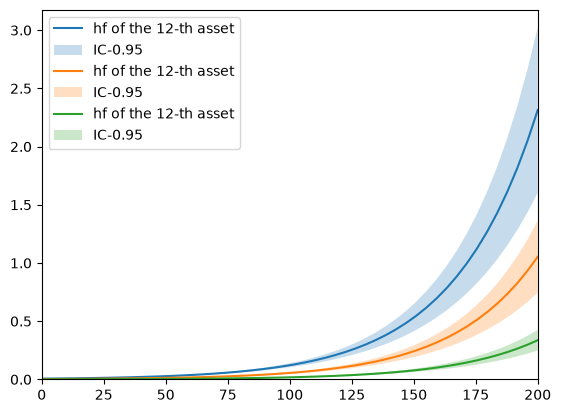

In [6]:
import numpy as np
import matplotlib.pyplot as plt

i, j, k = 12, 1073, 7999

timeline = np.linspace(0, 200)
regression.plot("hf", timeline, z1[i], z2[i], z3[i], label=f"hf of the {i}-th asset")
regression.plot("hf", timeline, z1[j], z2[j], z3[j], label=f"hf of the {i}-th asset")
regression.plot("hf", timeline, z1[k], z2[k], z3[k], label=f"hf of the {i}-th asset")
plt.show()